# Titanic Survival Prediction

In [1]:

# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml


In [2]:

# Step 2: Load Dataset

titanic = fetch_openml(
    name="titanic",
    version=1,
    as_frame=True
)

df = titanic.frame

df.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:

# Step 3: Understand Dataset

print("Shape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
df.info()


Shape of Dataset
(1309, 14)

Columns
Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3),

In [4]:

# Step 4: Check Missing Values

df.isnull().sum()


,0
pclass,0
survived,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014


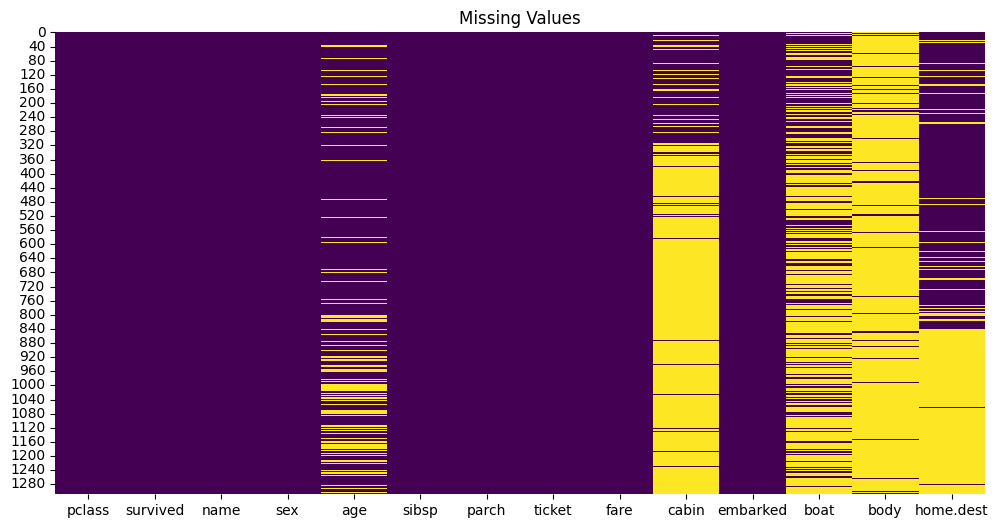

In [5]:

# Step 5: Visualize Missing Values

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values")
plt.show()


In [6]:
# Step 6: Handle Missing Values

df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df.drop("cabin", axis=1, inplace=True)

In [7]:
# Step 7: Verify Missing Values

df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
embarked,0


In [8]:
# Step 8 & 9: Label Encoding

from sklearn.preprocessing import LabelEncoder

sex_encoder = LabelEncoder()
df["sex"] = sex_encoder.fit_transform(df["sex"])

embarked_encoder = LabelEncoder()
df["embarked"] = embarked_encoder.fit_transform(df["embarked"])

df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",0,29.0000,0,0,24160,211.3375,2,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",1,0.9167,1,2,113781,151.5500,2,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",0,2.0000,1,2,113781,151.5500,2,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",1,30.0000,1,2,113781,151.5500,2,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",0,25.0000,1,2,113781,151.5500,2,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [9]:
# Step 10: One Hot Encoding Example

pd.get_dummies(df["embarked"], prefix="Embarked").head()

,Embarked_0,Embarked_1,Embarked_2
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True


In [10]:
# Step 11: Remove Unnecessary Columns

df.drop(
    ["name","ticket","boat","body","home.dest"],
    axis=1,
    inplace=True
)

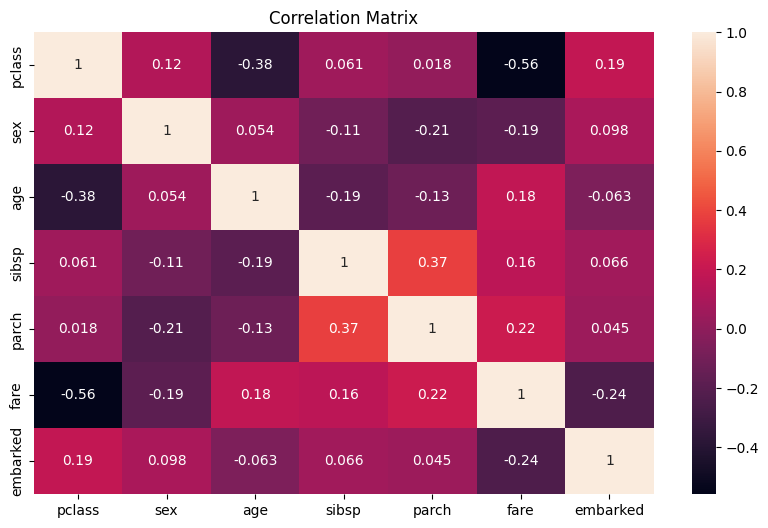

In [11]:
# Step 12: Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

In [12]:
# Step 13: Feature and Target

X = df.drop("survived", axis=1)
y = df["survived"]

In [13]:
# Step 14: Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7786259541984732


In [15]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7709923664122137


In [16]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7977099236641222


In [17]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)


KNN Accuracy: 0.6908396946564885


In [18]:
# SVM

from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6183206106870229


In [19]:
# Model Comparison

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.778626
1,Decision Tree,0.770992
2,Random Forest,0.797710
3,KNN,0.690840
4,SVM,0.618321


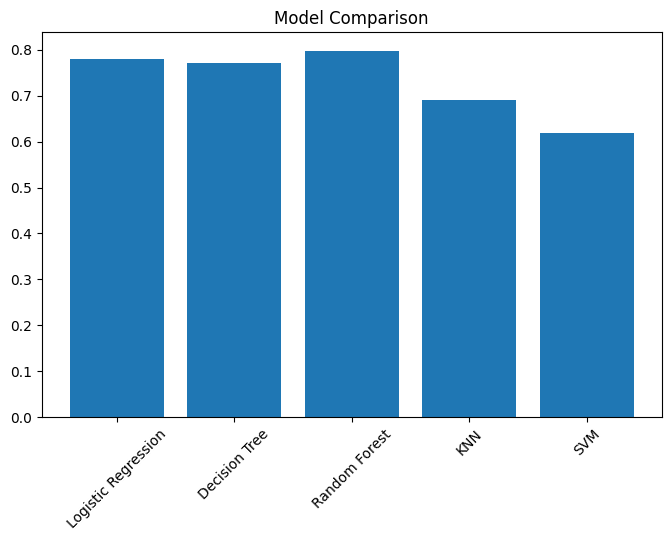

In [20]:
# Accuracy Visualization

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.xticks(rotation=45)

plt.title("Model Comparison")

plt.show()

In [21]:
# Multiple Evaluation Metrics

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

y_test_int = y_test.astype(int)
rf_pred_int = rf_pred.astype(int)

print("Accuracy :", accuracy_score(y_test_int, rf_pred_int))
print("Precision:", precision_score(y_test_int, rf_pred_int))
print("Recall   :", recall_score(y_test_int, rf_pred_int))
print("F1 Score :", f1_score(y_test_int, rf_pred_int))

Accuracy : 0.7977099236641222
Precision: 0.8282828282828283
Recall   : 0.6949152542372882
F1 Score : 0.7557603686635944


In [22]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83       144
           1       0.83      0.69      0.76       118

    accuracy                           0.80       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.80      0.80       262



In [23]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[127  17]
 [ 36  82]]


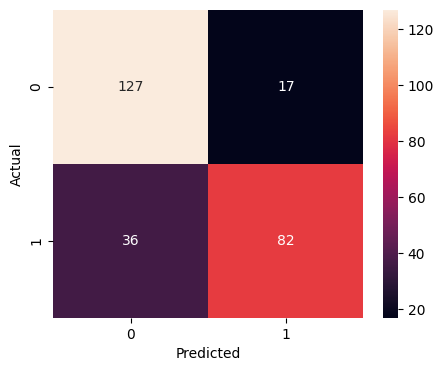

In [24]:
# Confusion Matrix Visualization

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
# Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print(scores)
print("Average Accuracy:", scores.mean())

[0.5        0.73664122 0.66412214 0.69847328 0.64750958]
Average Accuracy: 0.6493492439530871


In [26]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

parameters = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,15]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    parameters,
    cv=5
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': 5, 'n_estimators': 100}


In [27]:
# Best Model

best_rf = RandomForestClassifier(
    n_estimators=grid_search.best_params_["n_estimators"],
    max_depth=grid_search.best_params_["max_depth"]
)

best_rf.fit(X_train, y_train)

final_pred = best_rf.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, final_pred))

Final Accuracy: 0.7519083969465649
